In [2]:
%pip install kmodes


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


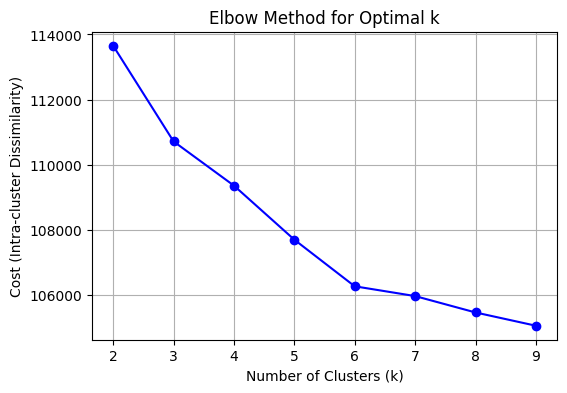

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.decomposition import PCA

# Load your dataset
df = pd.read_csv(r"C:\Users\alexa\Thesis\filtered_au_data.csv")  # Replace with your file if needed

# Elbow Method: Determine best number of clusters
costs = []
K_range = range(2, 10)

for k in K_range:
    km = KModes(n_clusters=k, init="Huang", n_init=5, verbose=0, random_state=42)
    km.fit(df)
    costs.append(km.cost_)

# Plot Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(K_range, costs, marker="o", linestyle="-", color="b")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost (Intra-cluster Dissimilarity)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()



In [11]:
best_k = 4  # Replace this with your chosen optimal k

kmodes = KModes(n_clusters=best_k, init="Huang", n_init=5, verbose=0, random_state=42)
df["Cluster"] = kmodes.fit_predict(df)

# Save the clustered data
df.to_csv("clustered_au_data.csv", index=False)

# Print cluster counts
print(df["Cluster"].value_counts())


Cluster
0    2753
1    1621
2    1450
3    1232
Name: count, dtype: int64


In [12]:
print(df.dtypes)


Source      object
AU01_r     float64
AU02_r     float64
AU04_r     float64
AU05_r     float64
AU06_r     float64
AU07_r     float64
AU09_r     float64
AU10_r     float64
AU12_r     float64
AU14_r     float64
AU15_r     float64
AU17_r     float64
AU20_r     float64
AU23_r     float64
AU25_r     float64
AU26_r     float64
AU45_r     float64
AU01_c     float64
AU02_c     float64
AU04_c     float64
AU05_c     float64
AU06_c     float64
AU07_c     float64
AU09_c     float64
AU10_c     float64
AU12_c     float64
AU14_c     float64
AU15_c     float64
AU17_c     float64
AU20_c     float64
AU23_c     float64
AU25_c     float64
AU26_c     float64
AU28_c     float64
AU45_c     float64
Cluster     uint16
dtype: object


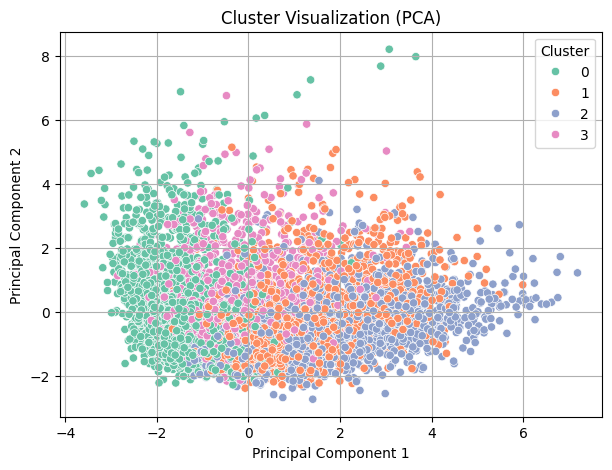

In [13]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.drop(columns=["Cluster", "Source"]))  # Drop non-numeric column
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster"]


# Plot clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=df_pca["Cluster"], palette="Set2")
plt.title("Cluster Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


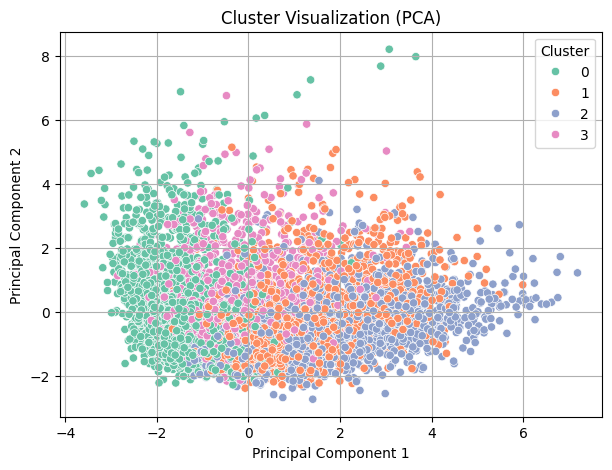

TypeError: agg function failed [how->mean,dtype->object]

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Assuming df is your DataFrame with the original data and cluster assignments

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.drop(columns=["Cluster", "Source"]))  # Drop non-numeric column
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster"]

# Plot clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=df_pca["Cluster"], palette="Set2")
plt.title("Cluster Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

# Analyze cluster characteristics
cluster_summary = df.groupby("Cluster").mean()
print("Cluster Summary Statistics:")
print(cluster_summary)

# Visualize cluster centers
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary.T, annot=True, cmap="coolwarm")
plt.title("Cluster Centers")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.show()

# Additional analysis: distribution of features within each cluster
for cluster in df["Cluster"].unique():
    cluster_data = df[df["Cluster"] == cluster]
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=cluster_data.drop(columns=["Cluster", "Source"]))
    plt.title(f"Feature Distribution for Cluster {cluster}")
    plt.xticks(rotation=90)
    plt.show()